In [ ]:
To analyze customer behavior using statistical and mathematical tools in Python, to
identify factors affecting customer retention and churn.
Get the dataset from :
https://drive.google.com/file/d/1VX-LFyvlpQf7T_6lMnco0DKn6-5PtA1q/view?usp=
drive_link
Dataset Description:
Assume a dataset with the following columns:
1. CustomerID
2. Gender
3. Region
4. PurchaseAmount
5. ProductCategory
6. Churn (Yes/No)
7. CampaignGroup (A/B)
Questions
1. What is the average, median, and mode of PurchaseAmount?
2. Are there any outliers in the PurchaseAmount data?
3. Is there any skewness or kurtosis in the PurchaseAmount distribution?
4. Is there a significant difference in spending between male and female
customers?
5. Is there a relationship between ProductCategory and customer churn?
6. Does PurchaseAmount vary significantly across different regions?
7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?
8. Can we assume PurchaseAmount follows a normal distribution?
9. What insights can we gain by applying the Central Limit Theorem?
10.What is the 95% confidence interval for the average PurchaseAmount?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("customer_behavior.csv")

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory',
       'Churn', 'CampaignGroup'],
      dtype='object')

In [5]:
df.shape

(5000, 7)

In [6]:
df["PurchaseAmount"].dropna().mean()

np.float64(1003.9506701030928)

In [7]:
avg = df["PurchaseAmount"].mean()

In [8]:
df["PurchaseAmount"].head()

0     256.07
1        NaN
2    1194.41
3     413.06
4    1556.32
Name: PurchaseAmount, dtype: float64

In [9]:
expected_cols = ['CustomerID','Gender','Region','PurchaseAmount','ProductCategory','Churn','CampaignGroup']

In [10]:
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError("Missing columns from dataset: " + ", ".join(missing))


In [11]:
n_before = len(df)
df = df.dropna(subset=['PurchaseAmount'])

In [12]:
print(f"Dropped {n_before - len(df)} rows due to missing PurchaseAmount")

Dropped 150 rows due to missing PurchaseAmount


# 1. What is the average, median, and mode of PurchaseAmount?

In [13]:
data = df.copy()
purchase = data['PurchaseAmount'].dropna()

mean_purchase = purchase.mean()
median_purchase = purchase.median()


In [14]:
from collections import Counter

In [15]:
counts = Counter(purchase)
max_count = max(counts.values())
modes = sorted([val for val,count in counts.items() if count==max_count])


In [16]:
print("Mean:", mean_purchase)
print("Median:", median_purchase)
print("Mode:", modes, "(counts = {})".format(max_count))

Mean: 1003.9506701030928
Median: 998.0799999999999
Mode: [0.0] (counts = 102)


In [17]:
# Standardize churn to Yes/No and campaign to A/B
df['Churn'] = df['Churn'].astype(str).str.strip().str.capitalize()
df['CampaignGroup'] = df['CampaignGroup'].astype(str).str.strip().str.upper()
df['Gender'] = df['Gender'].astype(str).str.strip().str.capitalize()

# 2. Are there any outliers in the PurchaseAmount data?

In [18]:
Q1 = purchase.quantile(0.25)
Q3 = purchase.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = purchase[(purchase < lower_bound) | (purchase > upper_bound)]
perc_outliers_iqr = len(outliers_iqr) / len(purchase) * 100

In [19]:
print(f"IQR method: {len(outliers_iqr)} outliers ({perc_outliers_iqr:.2f}%)")
print("IQR bounds:", lower_bound, "-", upper_bound)

IQR method: 15 outliers (0.31%)
IQR bounds: -306.51000000000033 - 2307.2300000000005


# 3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [20]:
from scipy import stats

In [21]:
skewness = stats.skew(purchase, nan_policy='omit')
kurtosis = stats.kurtosis(purchase, nan_policy='omit')

In [22]:
print("Skewness:", skewness)
print("Kurtosis (excess):", kurtosis)

Skewness: 0.10605907900111372
Kurtosis (excess): -0.26247789221265183


# 4. Is there a significant difference in spending between male and female customers?

In [23]:
group_counts = data['Gender'].value_counts()
print("Gender counts:", group_counts)

Gender counts: Gender
Male      2386
Female    2370
Name: count, dtype: int64


In [24]:
male = data.loc[data['Gender'].str.startswith('M', na=False), 'PurchaseAmount']
female = data.loc[data['Gender'].str.startswith('F', na=False), 'PurchaseAmount']

stat_m, p_m = stats.shapiro(male.sample(min(500, len(male)))) if len(male) >= 3 else (np.nan, np.nan)
stat_f, p_f = stats.shapiro(female.sample(min(500, len(female)))) if len(female) >= 3 else (np.nan, np.nan)

print("Male p:", p_m, " Female p:", p_f)

Male p: 0.014071785992923198  Female p: 0.01235981708706642


In [25]:
lev_stat, lev_p = stats.levene(male, female, center='median')
print("Levene test p:", lev_p)


Levene test p: 0.49725940228261556


In [26]:
if (not np.isnan(p_m) and p_m > 0.05) and (not np.isnan(p_f) and p_f > 0.05) and lev_p > 0.05:
    t_stat, t_p = stats.ttest_ind(male, female, equal_var=True, nan_policy='omit')
    test_name = "Independent t-test (equal var)"
    test_stat, test_p = t_stat, t_p
else:
    mw_stat, mw_p = stats.mannwhitneyu(male, female, alternative='two-sided')
    test_name = "Mann-Whitney U test (nonparametric)"
    test_stat, test_p = mw_stat, mw_p

In [27]:
print("Test used:", test_name)
print("Statistic:", test_stat, " p-value:", test_p)
print("Male mean:", male.mean(), " Female mean:", female.mean())

Test used: Mann-Whitney U test (nonparametric)
Statistic: 2934903.5  p-value: 0.023185034915582468
Male mean: 1019.1766093880973  Female mean: 987.8720464135021


# 5. Is there a relationship between ProductCategory and customer churn?

In [28]:
ct = pd.crosstab(data['ProductCategory'], data['Churn'])
print("Contingency table (ProductCategory x Churn):", ct)


Contingency table (ProductCategory x Churn): Churn             No  Yes
ProductCategory          
Electronics      762  526
Fashion          811  587
Grocery          832  584


In [29]:
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))


In [30]:
print("Chi-square:", chi2, " p-value:", p_chi, " dof:", dof)
print("Cramer's V (effect size):", cramers_v)

Chi-square: 0.3799539860794437  p-value: 0.8269781599781735  dof: 2
Cramer's V (effect size): 0.009624267257999398


# 6. Does PurchaseAmount vary significantly across different regions?

In [31]:
regions = data['Region'].unique()
groups = [data.loc[data['Region']==r, 'PurchaseAmount'].dropna() for r in regions]

normal_pvals = []
for g in groups:
    if len(g) >= 3:
        _, p = stats.shapiro(g.sample(min(500, len(g))))
        normal_pvals.append(p)
    else:
        normal_pvals.append(np.nan)


In [32]:
print("Region normality p-values (sample-limited):", dict(zip(regions, normal_pvals)))

Region normality p-values (sample-limited): {'South': np.float64(0.098118742235333), 'West': np.float64(0.0062316857109914955), 'North': np.float64(0.010130611781652789), 'East': np.float64(0.013054760957709606), nan: nan}


In [33]:
levene_stat, levene_p = stats.levene(*groups, center='median')
print("Levene p:", levene_p)


Levene p: nan


C:\Users\shafeenausman\AppData\Local\Temp\ipykernel_6016\445594746.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  levene_stat, levene_p = stats.levene(*groups, center='median')


In [34]:
if all([p is not np.nan and p > 0.05 for p in normal_pvals if not np.isnan(p)]) and levene_p > 0.05:
    # ANOVA
    f_stat, f_p = stats.f_oneway(*groups)
    print("ANOVA F:", f_stat, " p-value:", f_p)
    test6_name = "One-way ANOVA"
    test6_stat, test6_p = f_stat, f_p
else:
    # Kruskal-Wallis
    kw_stat, kw_p = stats.kruskal(*groups)
    print("Kruskal-Wallis H:", kw_stat, " p-value:", kw_p)
    test6_name = "Kruskal-Wallis"
    test6_stat, test6_p = kw_stat, kw_p

Kruskal-Wallis H: nan  p-value: nan


C:\Users\shafeenausman\AppData\Local\Temp\ipykernel_6016\990962411.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  kw_stat, kw_p = stats.kruskal(*groups)


In [35]:
print("Test used:", test6_name, " statistic:", test6_stat, " p:", test6_p)

Test used: Kruskal-Wallis  statistic: nan  p: nan


# 7. Which email campaign (A or B) performed better in terms of average PurchaseAmount?


In [36]:
campaign_A = data.loc[data['CampaignGroup']=='A', 'PurchaseAmount']
campaign_B = data.loc[data['CampaignGroup']=='B', 'PurchaseAmount']
print("nCampaign A count:", len(campaign_A), " mean:", campaign_A.mean())
print("Campaign B count:", len(campaign_B), " mean:", campaign_B.mean())

nCampaign A count: 2350  mean: 1011.9455872340425
Campaign B count: 2318  mean: 994.3399654874893


In [37]:
_, pA = stats.shapiro(campaign_A.sample(min(500, len(campaign_A)))) if len(campaign_A) >= 3 else (np.nan, np.nan)
_, pB = stats.shapiro(campaign_B.sample(min(500, len(campaign_B)))) if len(campaign_B) >= 3 else (np.nan, np.nan)
lev_stat_ab, lev_p_ab = stats.levene(campaign_A, campaign_B, center='median')

if (not np.isnan(pA) and pA > 0.05) and (not np.isnan(pB) and pB > 0.05) and lev_p_ab > 0.05:
    t_stat_ab, t_p_ab = stats.ttest_ind(campaign_A, campaign_B, equal_var=True, nan_policy='omit')
    test_ab_name = "Independent t-test"
    test_ab_stat, test_ab_p = t_stat_ab, t_p_ab
else:
    mw_ab_stat, mw_ab_p = stats.mannwhitneyu(campaign_A, campaign_B, alternative='two-sided')
    test_ab_name = "Mann-Whitney U test"
    test_ab_stat, test_ab_p = mw_ab_stat, mw_ab_p

In [38]:
print("Test:", test_ab_name, " stat:", test_ab_stat, " p:", test_ab_p)

Test: Mann-Whitney U test  stat: 2790249.0  p: 0.14800323491929004


# 8. Can we assume PurchaseAmount follows a normal distribution?


In [39]:
sh_stat, sh_p = stats.shapiro(purchase.sample(min(5000, len(purchase)))) if len(purchase) >= 3 else (np.nan, np.nan)
ad_result = stats.anderson(purchase, dist='norm')


In [40]:
print("Shapiro-Wilk p:", sh_p)
print("Anderson-Darling statistic:", ad_result.statistic, " critical values:", ad_result.critical_values, "significance levels:", ad_result.significance_level)


Shapiro-Wilk p: 5.744127799488107e-12
Anderson-Darling statistic: 1.6404746671287285  critical values: [0.576 0.655 0.786 0.917 1.091] significance levels: [15.  10.   5.   2.5  1. ]


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

(array([153.,  77.,  98., 151., 169., 208., 220., 269., 314., 360., 366.,
        337., 354., 316., 304., 237., 210., 178., 150., 117.,  97.,  48.,
         45.,  30.,  14.,  15.,   4.,   4.,   1.,   4.]),
 array([   0.        ,   89.62933333,  179.25866667,  268.888     ,
         358.51733333,  448.14666667,  537.776     ,  627.40533333,
         717.03466667,  806.664     ,  896.29333333,  985.92266667,
        1075.552     , 1165.18133333, 1254.81066667, 1344.44      ,
        1434.06933333, 1523.69866667, 1613.328     , 1702.95733333,
        1792.58666667, 1882.216     , 1971.84533333, 2061.47466667,
        2151.104     , 2240.73333333, 2330.36266667, 2419.992     ,
        2509.62133333, 2599.25066667, 2688.88      ]),
 <BarContainer object of 30 artists>)

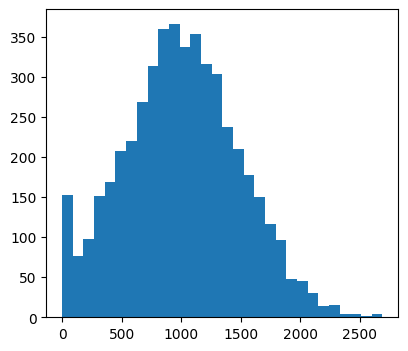

In [42]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(purchase, bins=30)


<Axes: >

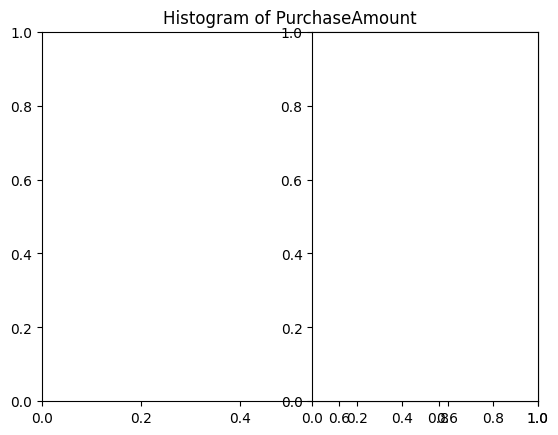

In [43]:
plt.title('Histogram of PurchaseAmount')
plt.subplot(1,2,2)


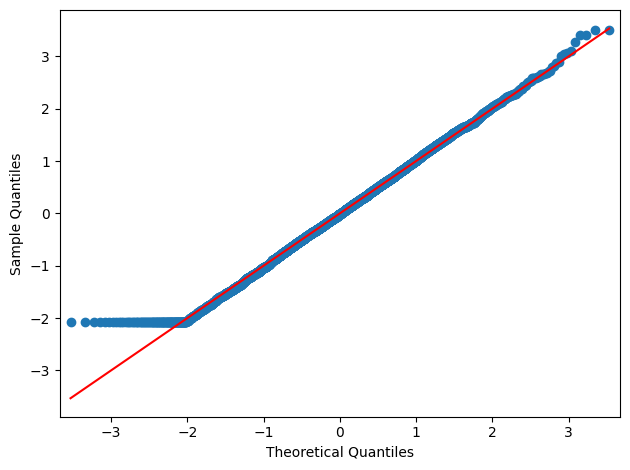

In [45]:
sm.qqplot(purchase, line='s', fit=True)
plt.tight_layout()


# 9. What insights can we gain by applying the Central Limit Theorem?

In [47]:
np.random.seed(42)
sample_size = 50
n_samples = 1000
sample_means = [purchase.sample(sample_size, replace=True).mean() for _ in range(n_samples)]

Sample means mean: 1004.1618164  std: 68.78233608379503


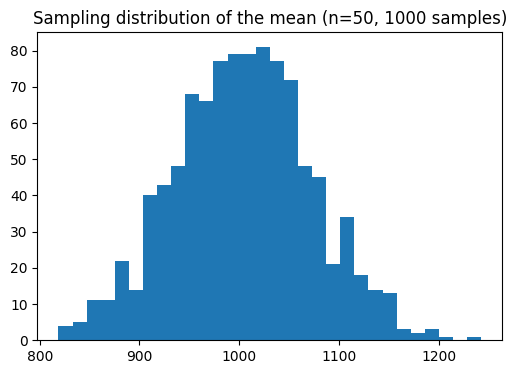

In [49]:
print("Sample means mean:", np.mean(sample_means), " std:", np.std(sample_means))
plt.figure(figsize=(6,4))
plt.hist(sample_means, bins=30)
plt.title(f"Sampling distribution of the mean (n={sample_size}, {n_samples} samples)")
plt.show()

# 10.What is the 95% confidence interval for the average PurchaseAmount?

In [50]:
n = len(purchase)
mean = purchase.mean()
std = purchase.std(ddof=1)
se = std / np.sqrt(n)

In [51]:
t_crit = stats.t.ppf(1-0.025, df=n-1)
ci_lower = mean - t_crit * se
ci_upper = mean + t_crit * se


In [52]:
print("n:", n, " mean:", mean, " std:", std)
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

n: 4850  mean: 1003.9506701030928  std: 482.11312193311574
95% CI: (990.3790, 1017.5224)
